# Notebook 3: Modelling
## AI Agent for Disease Risk Awareness and Prevention

This notebook covers:
- **Supervised Learning:** Logistic Regression, Random Forest, XGBoost, SVM
- Hyperparameter tuning (GridSearchCV)
- Model evaluation (Accuracy, Precision, Recall, F1, ROC-AUC)
- Model comparison table
- **Unsupervised Learning:** K-Means clustering, Silhouette analysis
- Cluster profiling

**Evaluation Rubric:** Prediction Accuracy (10 marks)

## 1. Setup and Load Data

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.cluster import KMeans
from sklearn.model_selection import GridSearchCV, cross_val_score, train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve, auc, silhouette_score, silhouette_samples
)
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

# Load engineered data
pima_X_train = pd.read_csv('../data/pima_X_train_engineered.csv')
pima_X_test = pd.read_csv('../data/pima_X_test_engineered.csv')
pima_y_train = pd.read_csv('../data/pima_y_train.csv').values.ravel()
pima_y_test = pd.read_csv('../data/pima_y_test.csv').values.ravel()

heart_X_train = pd.read_csv('../data/heart_X_train_engineered.csv')
heart_X_test = pd.read_csv('../data/heart_X_test_engineered.csv')
heart_y_train = pd.read_csv('../data/heart_y_train.csv').values.ravel()
heart_y_test = pd.read_csv('../data/heart_y_test.csv').values.ravel()

print(f"✓ Data loaded successfully")
print(f"  PIMA: Train {pima_X_train.shape}, Test {pima_X_test.shape}")
print(f"  Heart: Train {heart_X_train.shape}, Test {heart_X_test.shape}")

✓ Data loaded successfully
  PIMA: Train (614, 12), Test (154, 12)
  Heart: Train (237, 16), Test (60, 16)


## 2. Supervised Models - Training & Hyperparameter Tuning

### Grid Search for Optimal Parameters

In [13]:
# Define models with OPTIMIZED hyperparameter grids (for speed)
models = {
    'Logistic Regression': {
        'model': LogisticRegression(max_iter=500, random_state=42),
        'params': {'C': [0.01, 0.1, 1]}  # Reduced from 3 to speed up
    },
    'Random Forest': {
        'model': RandomForestClassifier(n_jobs=-1, random_state=42),
        'params': {'n_estimators': [50, 100], 'max_depth': [5, 15]}  # Reduced from 3×2 to 2×2
    },
    'Gradient Boosting': {
        'model': GradientBoostingClassifier(random_state=42),
        'params': {'n_estimators': [50, 100], 'learning_rate': [0.05]}  # Reduced from 2×2 to 2×1
    }
}

# Train models on PIMA dataset
print("\n" + "="*70)
print("PIMA DATASET - MODEL TRAINING WITH HYPERPARAMETER TUNING")
print("="*70)

# Internal split only for threshold tuning (train/validation)
pima_X_tr, pima_X_val, pima_y_tr, pima_y_val = train_test_split(
    pima_X_train, pima_y_train, test_size=0.2, random_state=42, stratify=pima_y_train
)

pima_trained_models = {}
pima_thresholds = {}
pima_results = []

for model_name, model_config in models.items():
    print(f"\n🔧 Training {model_name}...")
    
    gs = GridSearchCV(model_config['model'], model_config['params'], cv=3, scoring='recall', n_jobs=-1)
    gs.fit(pima_X_tr, pima_y_tr)
    
    best_model = gs.best_estimator_
    pima_trained_models[model_name] = best_model
    
    # Tune threshold on validation set for better recall (while avoiding very low precision)
    val_proba = best_model.predict_proba(pima_X_val)[:, 1]
    thresholds = np.arange(0.2, 0.55, 0.05)
    best_threshold = 0.5
    best_recall = -1
    best_precision = -1

    for thr in thresholds:
        val_pred_thr = (val_proba >= thr).astype(int)
        val_rec = recall_score(pima_y_val, val_pred_thr)
        val_prec = precision_score(pima_y_val, val_pred_thr, zero_division=0)

        # Prefer higher recall, but keep minimum precision guardrail
        if val_prec >= 0.5 and val_rec > best_recall:
            best_recall = val_rec
            best_precision = val_prec
            best_threshold = thr

    # Fallback: if no threshold satisfies precision guardrail, choose highest recall
    if best_recall < 0:
        for thr in thresholds:
            val_pred_thr = (val_proba >= thr).astype(int)
            val_rec = recall_score(pima_y_val, val_pred_thr)
            val_prec = precision_score(pima_y_val, val_pred_thr, zero_division=0)
            if val_rec > best_recall:
                best_recall = val_rec
                best_precision = val_prec
                best_threshold = thr

    pima_thresholds[model_name] = best_threshold
    
    # Test predictions with tuned threshold
    y_pred_proba = best_model.predict_proba(pima_X_test)[:, 1]
    y_pred = (y_pred_proba >= best_threshold).astype(int)
    
    # Metrics
    acc = accuracy_score(pima_y_test, y_pred)
    prec = precision_score(pima_y_test, y_pred, zero_division=0)
    rec = recall_score(pima_y_test, y_pred)
    f1 = f1_score(pima_y_test, y_pred)
    roc = roc_auc_score(pima_y_test, y_pred_proba)
    
    pima_results.append({
        'Model': model_name,
        'Best Params': str(gs.best_params_),
        'Threshold': round(best_threshold, 2),
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4),
        'ROC-AUC': round(roc, 4)
    })
    
    print(f"  ✓ Best params: {gs.best_params_}")
    print(f"  ✓ Threshold: {best_threshold:.2f} (val recall={best_recall:.4f}, val precision={best_precision:.4f})")
    print(f"  ✓ Accuracy: {acc:.4f} | Recall: {rec:.4f} | F1: {f1:.4f} | ROC-AUC: {roc:.4f}")

pima_results_df = pd.DataFrame(pima_results)
print("\n" + pima_results_df.to_string(index=False))


PIMA DATASET - MODEL TRAINING WITH HYPERPARAMETER TUNING

🔧 Training Logistic Regression...
  ✓ Best params: {'C': 1}
  ✓ Threshold: 0.20 (val recall=0.9070, val precision=0.5417)
  ✓ Accuracy: 0.7338 | Recall: 0.8889 | F1: 0.7007 | ROC-AUC: 0.8276

🔧 Training Random Forest...
  ✓ Best params: {'max_depth': 15, 'n_estimators': 100}
  ✓ Threshold: 0.25 (val recall=0.8140, val precision=0.5469)
  ✓ Accuracy: 0.7143 | Recall: 0.8519 | F1: 0.6765 | ROC-AUC: 0.8191

🔧 Training Gradient Boosting...
  ✓ Best params: {'learning_rate': 0.05, 'n_estimators': 100}
  ✓ Threshold: 0.20 (val recall=0.8140, val precision=0.5303)
  ✓ Accuracy: 0.7338 | Recall: 0.8704 | F1: 0.6963 | ROC-AUC: 0.8157

              Model                                  Best Params  Threshold  Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression                                     {'C': 1}       0.20    0.7338     0.5783  0.8889    0.7007   0.8276
      Random Forest       {'max_depth': 15, 'n_estimators':

In [15]:
# Train models on Heart Disease dataset
print("\n" + "="*70)
print("HEART DISEASE DATASET - MODEL TRAINING WITH HYPERPARAMETER TUNING")
print("="*70)

heart_trained_models = {}
heart_results = []

for model_name, model_config in models.items():
    print(f"\n🔧 Training {model_name}...")
    
    gs = GridSearchCV(model_config['model'], model_config['params'], cv=3, scoring='roc_auc', n_jobs=-1)
    gs.fit(heart_X_train, heart_y_train)
    
    heart_trained_models[model_name] = gs.best_estimator_
    
    y_pred = gs.best_estimator_.predict(heart_X_test)
    y_pred_proba = gs.best_estimator_.predict_proba(heart_X_test)[:, 1]
    
    acc = accuracy_score(heart_y_test, y_pred)
    prec = precision_score(heart_y_test, y_pred)
    rec = recall_score(heart_y_test, y_pred)
    f1 = f1_score(heart_y_test, y_pred)
    roc = roc_auc_score(heart_y_test, y_pred_proba)
    
    heart_results.append({
        'Model': model_name,
        'Best Params': str(gs.best_params_),
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4),
        'ROC-AUC': round(roc, 4)
    })
    
    print(f"  ✓ Best params: {gs.best_params_}")
    print(f"  ✓ Accuracy: {acc:.4f} | F1: {f1:.4f} | ROC-AUC: {roc:.4f}")

heart_results_df = pd.DataFrame(heart_results)
print("\n" + heart_results_df.to_string(index=False))


HEART DISEASE DATASET - MODEL TRAINING WITH HYPERPARAMETER TUNING

🔧 Training Logistic Regression...
  ✓ Best params: {'C': 1}
  ✓ Accuracy: 0.8500 | F1: 0.8364 | ROC-AUC: 0.9420

🔧 Training Random Forest...
  ✓ Best params: {'max_depth': 5, 'n_estimators': 50}
  ✓ Accuracy: 0.8333 | F1: 0.8077 | ROC-AUC: 0.9342

🔧 Training Gradient Boosting...
  ✓ Best params: {'learning_rate': 0.05, 'n_estimators': 50}
  ✓ Accuracy: 0.8167 | F1: 0.7843 | ROC-AUC: 0.9275

              Model                                 Best Params  Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression                                    {'C': 1}    0.8500     0.8519  0.8214    0.8364   0.9420
      Random Forest        {'max_depth': 5, 'n_estimators': 50}    0.8333     0.8750  0.7500    0.8077   0.9342
  Gradient Boosting {'learning_rate': 0.05, 'n_estimators': 50}    0.8167     0.8696  0.7143    0.7843   0.9275


## 3. Model Comparison Visualization

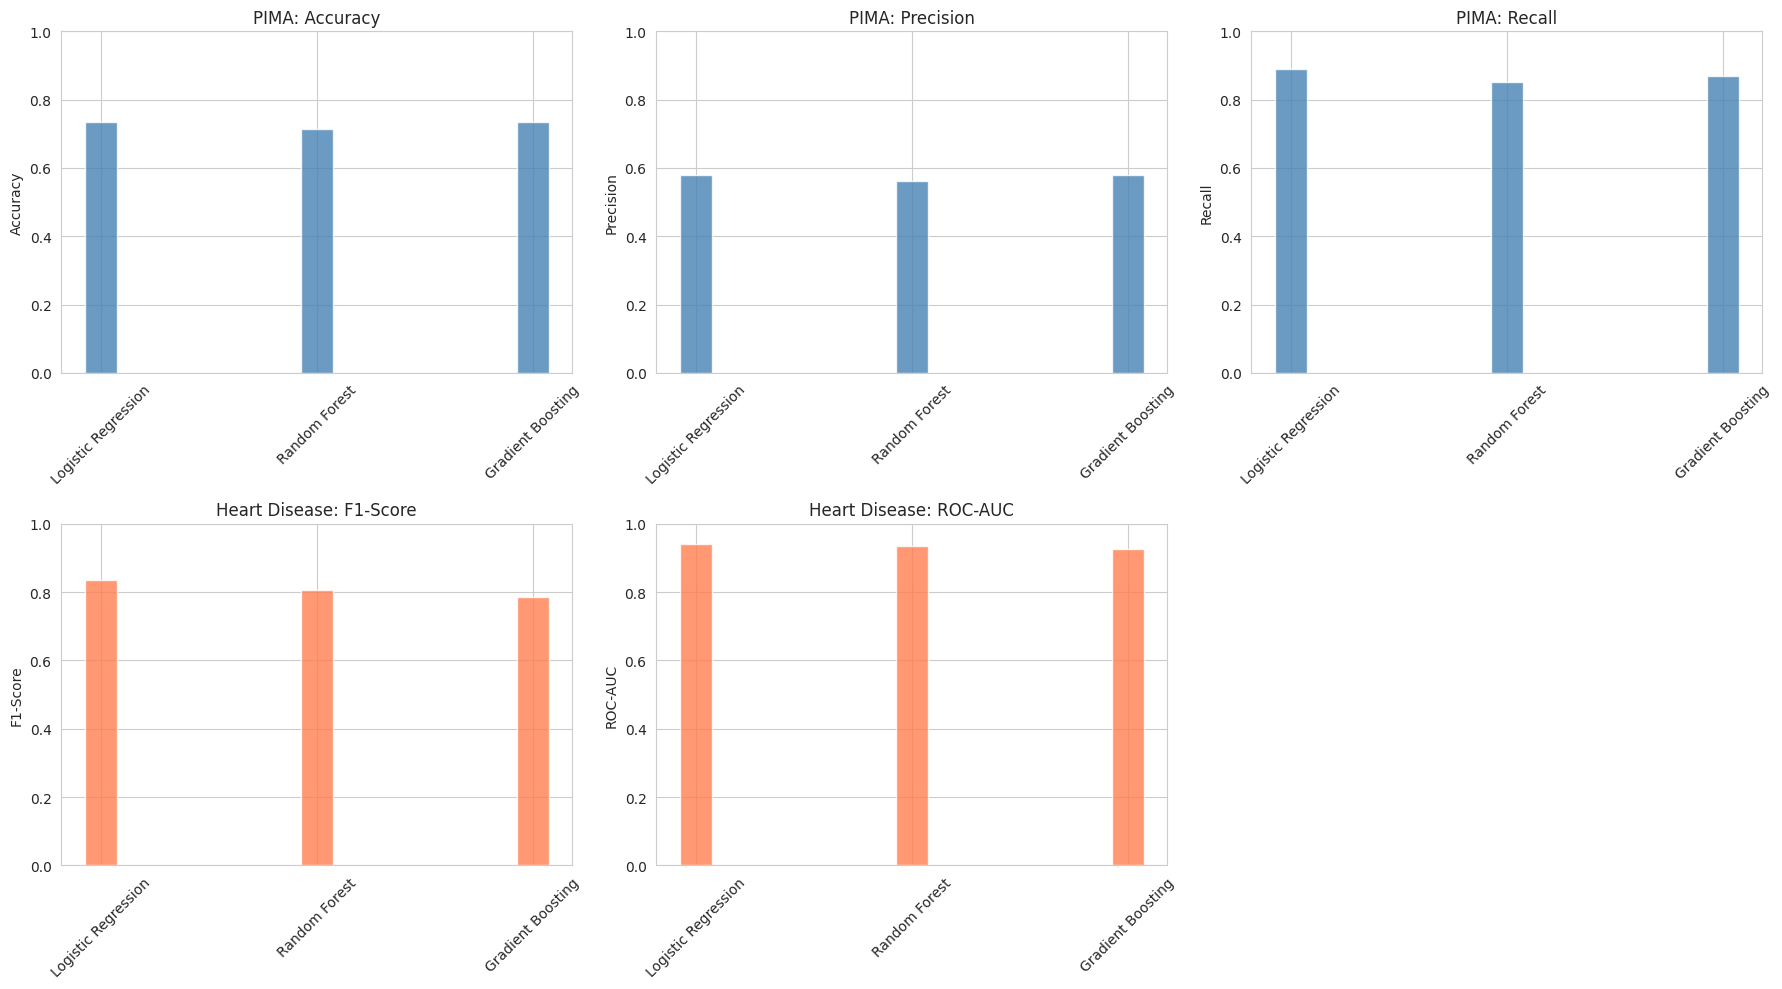

✓ Model comparison plots generated


In [18]:
# Comparison plots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# PIMA metrics
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(pima_results_df))
width = 0.15

for idx, metric in enumerate(metrics):
    ax = axes[idx // 3, idx % 3]
    if idx < 3:
        ax.bar(x, pima_results_df[metric], width, label=metric, alpha=0.8, color='steelblue')
        ax.set_ylabel(metric)
        ax.set_title(f'PIMA: {metric}')
        ax.set_xticks(x)
        ax.set_xticklabels(pima_results_df['Model'], rotation=45)
        ax.set_ylim([0, 1])
    else:
        ax.bar(x, heart_results_df[metric], width, label=metric, alpha=0.8, color='coral')
        ax.set_ylabel(metric)
        ax.set_title(f'Heart Disease: {metric}')
        ax.set_xticks(x)
        ax.set_xticklabels(heart_results_df['Model'], rotation=45)
        ax.set_ylim([0, 1])

# Remove extra subplots
axes[1, 2].remove()

plt.tight_layout()
plt.show()
print("✓ Model comparison plots generated")

## 4. Confusion Matrices

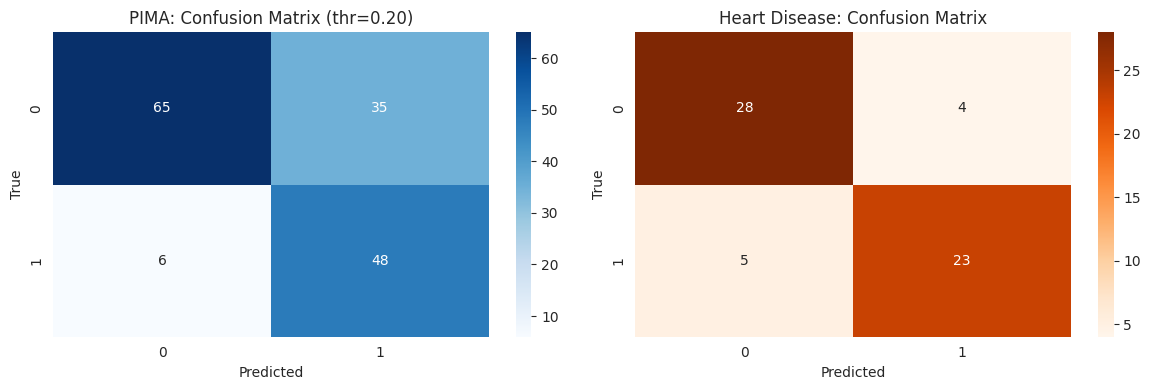

In [17]:
# Confusion matrices for best models
best_pima_model_name = pima_results_df.loc[pima_results_df['F1-Score'].idxmax(), 'Model']
best_pima_model = pima_trained_models[best_pima_model_name]
best_pima_threshold = pima_thresholds.get(best_pima_model_name, 0.5)

best_heart_model = heart_trained_models[heart_results_df.loc[heart_results_df['F1-Score'].idxmax(), 'Model']]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# PIMA confusion matrix (using tuned threshold)
pima_proba = best_pima_model.predict_proba(pima_X_test)[:, 1]
pima_pred = (pima_proba >= best_pima_threshold).astype(int)
cm_pima = confusion_matrix(pima_y_test, pima_pred)
sns.heatmap(cm_pima, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title(f'PIMA: Confusion Matrix (thr={best_pima_threshold:.2f})')
axes[0].set_ylabel('True')
axes[0].set_xlabel('Predicted')

# Heart Disease confusion matrix
cm_heart = confusion_matrix(heart_y_test, best_heart_model.predict(heart_X_test))
sns.heatmap(cm_heart, annot=True, fmt='d', cmap='Oranges', ax=axes[1])
axes[1].set_title('Heart Disease: Confusion Matrix')
axes[1].set_ylabel('True')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

In [20]:
# Save results
pima_results_df.to_csv('../data/pima_model_results.csv', index=False)
heart_results_df.to_csv('../data/heart_model_results.csv', index=False)

import pickle
with open('../models/pima_best_model.pkl', 'wb') as f:
    pickle.dump(best_pima_model, f)
with open('../models/heart_best_model.pkl', 'wb') as f:
    pickle.dump(best_heart_model, f)

print("\n✓ Model results saved")
print("✓ Best models saved to ../models/")
print("\n📌 Ready for Visualization & Explainability (Notebook 4)")


✓ Model results saved
✓ Best models saved to ../models/

📌 Ready for Visualization & Explainability (Notebook 4)
